In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob


In [3]:
df = pd.read_csv('/Users/andy/_data/all-states-train.csv')


In [4]:
df.head()

,rating,text
0,4,Awesome service and really great food
1,5,"Excellent wings, great staff"
2,1,Asked for a Vegitarian green burrito. I receiv...
3,5,Excellent food and service!
4,3,During lunch staff not friendly seems more dis...


## (1) Ratings Distribution

<Axes: title={'center': 'Star Rating Distribution'}, xlabel='rating'>

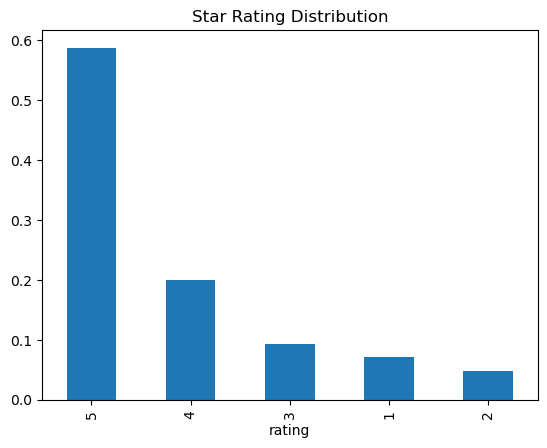

In [ ]:
df['rating'].value_counts(normalize=True).plot(kind='bar', title='Star Rating Distribution')

In [8]:
rating_counts = df['rating'].value_counts().sort_index()
rating_percentages = df['rating'].value_counts(normalize=True).sort_index() * 100

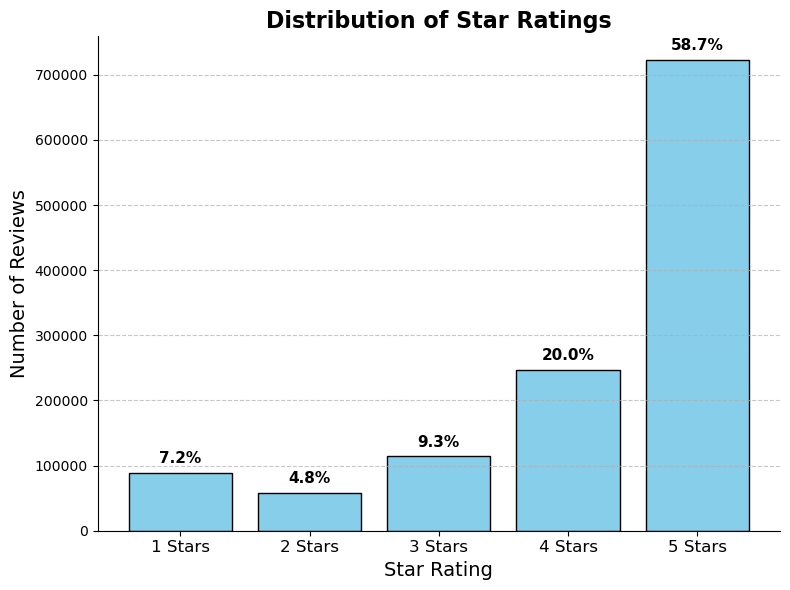

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(rating_counts.index, rating_counts.values, color='skyblue', edgecolor='black')

# Adding annotations (percentages) above the bars
for bar, percent in zip(bars, rating_percentages):
    height = bar.get_height()
    ax.annotate(f'{percent:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # Offset label position above the bar
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold')

# Customize the axes and title
ax.set_xlabel('Star Rating', fontsize=14)
ax.set_ylabel('Number of Reviews', fontsize=14)
ax.set_title('Distribution of Star Ratings', fontsize=16, fontweight='bold')
ax.set_xticks(rating_counts.index)
ax.set_xticklabels([f'{int(x)} Stars' for x in rating_counts.index], fontsize=12)

# Removing unnecessary spines for visual cleanliness
ax.spines[['right', 'top']].set_visible(False)

# Adjust gridlines for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


## (2) Review Length Analysis

In [11]:
# Character count per review
df['char_count'] = df['text'].apply(len)

# Word count per review
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Summarize statistics
length_summary = df[['char_count', 'word_count']].describe()
print(length_summary)


         char_count    word_count
count  1.230642e+06  1.230642e+06
mean   1.145732e+02  2.079525e+01
std    1.721633e+02  3.205234e+01
min    1.000000e+00  1.000000e+00
25%    2.800000e+01  5.000000e+00
50%    5.900000e+01  1.000000e+01
75%    1.310000e+02  2.400000e+01
max    5.870000e+03  8.060000e+02


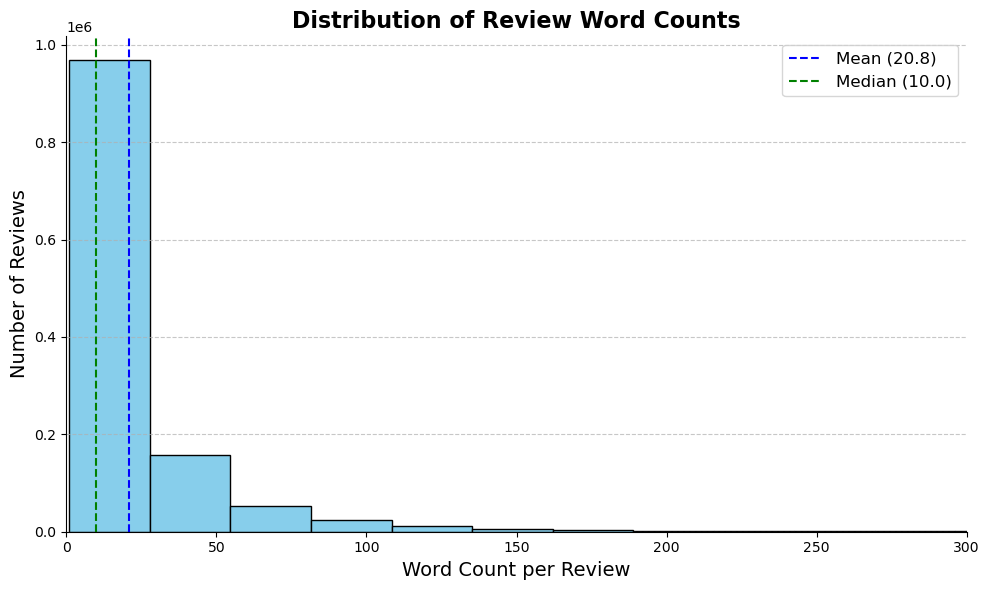

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of word counts
ax.hist(df['word_count'], bins=30, color='skyblue', edgecolor='black')

# Calculate mean and median for annotations
mean_wc = df['word_count'].mean()
median_wc = df['word_count'].median()

# Plotting mean and median lines
ax.axvline(mean_wc, color='blue', linestyle='--', linewidth=1.5, label=f'Mean ({mean_wc:.1f})')
ax.axvline(median_wc, color='green', linestyle='--', linewidth=1.5, label=f'Median ({median_wc:.1f})')

# Customize plot
ax.set_title('Distribution of Review Word Counts', fontsize=16, fontweight='bold')
ax.set_xlabel('Word Count per Review', fontsize=14)
ax.set_ylabel('Number of Reviews', fontsize=14)

# Adding legend for mean and median lines
ax.legend(fontsize=12)

# Gridlines for improved readability
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Remove unnecessary spines
ax.spines[['right', 'top']].set_visible(False)

ax.set_xlim(0, 300)

plt.tight_layout()
plt.show()


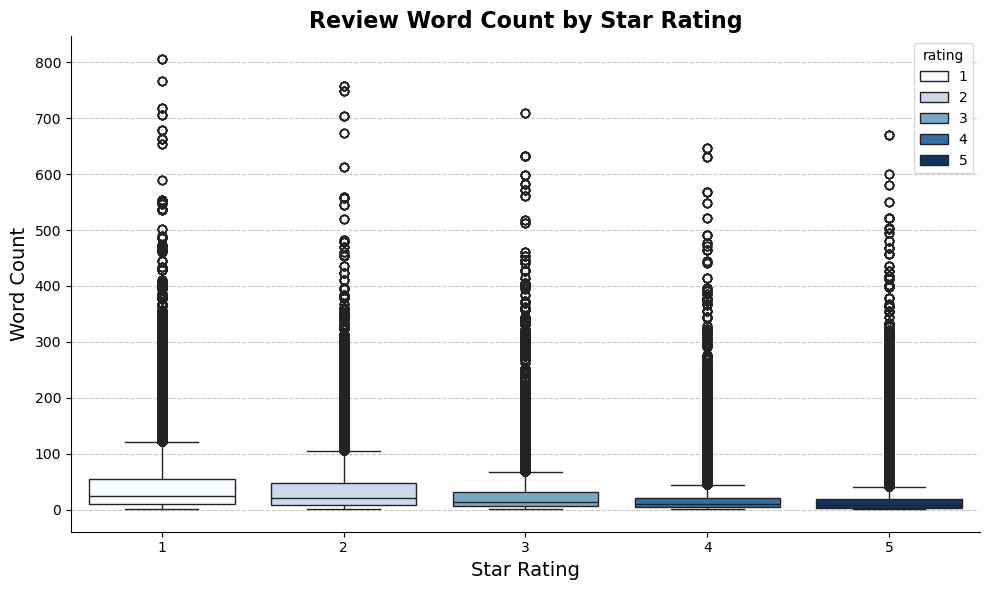

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='rating', y='word_count', data=df, palette='Blues', ax=ax, hue='rating')
ax.set_title('Review Word Count by Star Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=14)
ax.set_ylabel('Word Count', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()


Longer reviews are negatively correlated with rating...

## (3) Common Words and N-Grams

In [48]:
# Vectorizer setup for 1 to 3 word sequences, removing English stop words
vectorizer = CountVectorizer(stop_words='english', ngram_range=(1, 3))

# Fit-transform on review texts
X = vectorizer.fit_transform(df['text'])

# Summing counts for each word/ngram
word_counts = X.sum(axis=0).A1
word_freq = dict(zip(vectorizer.get_feature_names_out(), word_counts))

# Convert to DataFrame for easy analysis
freq_df = pd.DataFrame(word_freq.items(), columns=['term', 'count'])
freq_df = freq_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Display top 15 most frequent words/phrases
print(freq_df.head(20))


          term   count
0         food  570425
1        great  395627
2         good  385361
3      service  288174
4        place  184048
5        staff  107637
6         best   99096
7     friendly   97277
8         love   94857
9         time   91541
10        nice   89772
11  great food   85113
12   delicious   80672
13   good food   79970
14        like   74810
15   excellent   72975
16       order   72842
17        just   70812
18       pizza   59971
19     chicken   58125


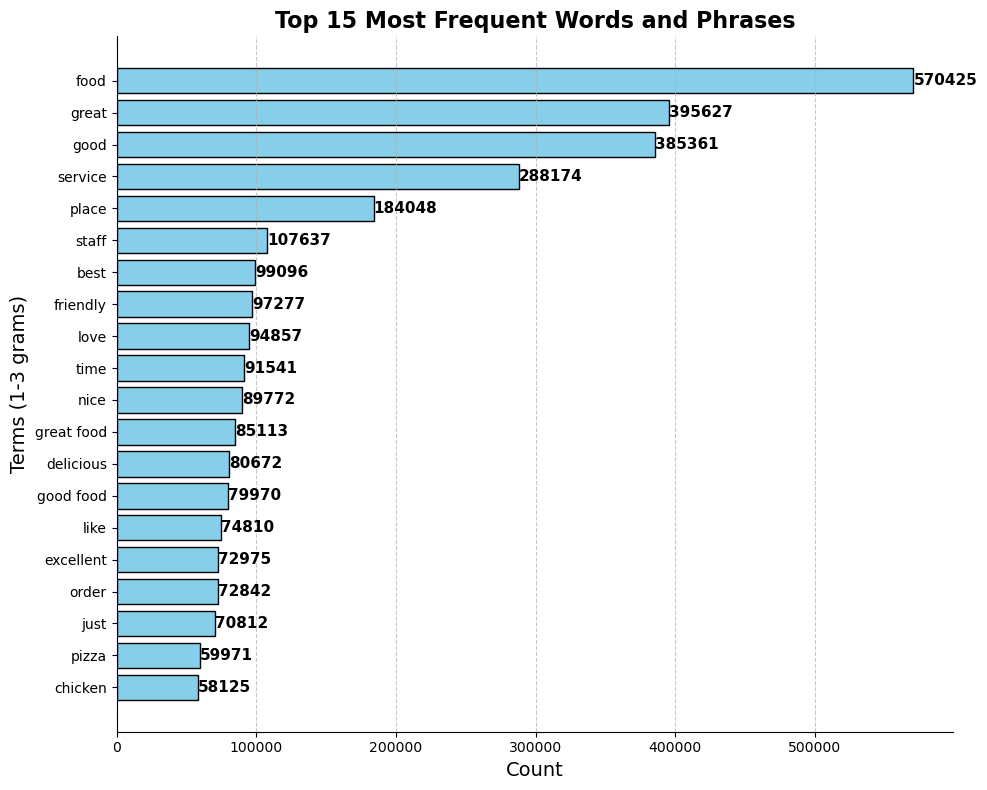

In [20]:
top_n = 20 # 15
top_terms = freq_df.head(top_n).sort_values(by='count')

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(top_terms['term'], top_terms['count'], color='skyblue', edgecolor='black')

# Annotate counts next to bars
for i, (count, term) in enumerate(zip(top_terms['count'], top_terms['term'])):
    ax.text(count + 2, i, str(count), va='center', fontsize=11, fontweight='bold')

# Aesthetic improvements
ax.set_title('Top 15 Most Frequent Words and Phrases', fontsize=16, fontweight='bold')
ax.set_xlabel('Count', fontsize=14)
ax.set_ylabel('Terms (1-3 grams)', fontsize=14)
ax.grid(axis='x', linestyle='--', alpha=0.7)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()


In [50]:
def top_words_by_rating(df, rating, top_n=10):
    vectorizer = CountVectorizer(stop_words='english')
    rating_text = df[df['rating'] == rating]['text']
    X = vectorizer.fit_transform(rating_text)
    word_counts = X.sum(axis=0).A1
    word_freq = dict(zip(vectorizer.get_feature_names_out(), word_counts))
    top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:top_n]
    return pd.DataFrame(top_words, columns=['word', 'count']).sort_values('count', ascending=True)

# Get top words for each rating
ratings = sorted(df['rating'].unique())
top_words_dict = {rating: top_words_by_rating(df, rating, top_n=8) for rating in ratings}


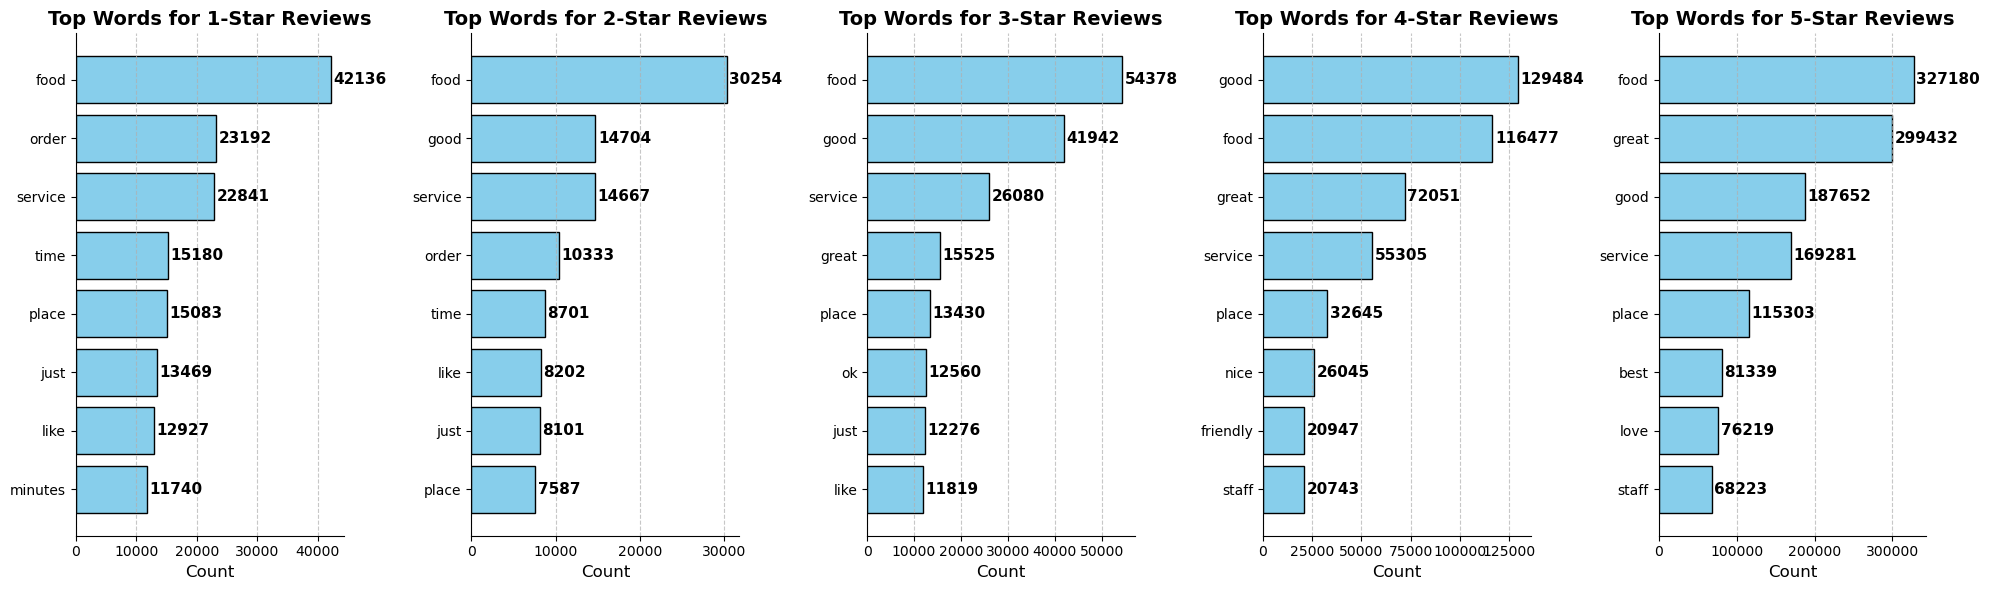

In [51]:
fig, axes = plt.subplots(nrows=1, ncols=len(ratings), figsize=(20, 6), sharey=False)

for ax, rating in zip(axes, ratings):
    data = top_words_dict[rating]
    ax.barh(data['word'], data['count'], color='skyblue', edgecolor='black')
    
    # Annotate bar counts
    for i, (word, count) in enumerate(zip(data['word'], data['count'])):
        ax.text(count + max(data['count']) * 0.01, i, str(count), va='center', fontsize=11, fontweight='bold')
    
    # Aesthetic improvements
    ax.set_title(f'Top Words for {rating}-Star Reviews', fontsize=14, fontweight='bold')
    ax.set_xlabel('Count', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()


## (4) Sentiment Scores

In [ ]:
df['sentiment'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [ ]:
df.groupby('rating')['sentiment'].describe()

,count,mean,std,min,25%,50%,75%,max
rating,,,,,,,,
1,88628.0,-0.154854,0.336868,-1.0,-0.325000,-0.096429,0.016667,1.0
2,58546.0,-0.000782,0.314571,-1.0,-0.164187,0.000000,0.169740,1.0
3,114011.0,0.205467,0.311048,-1.0,0.000000,0.200000,0.425556,1.0
4,246551.0,0.440824,0.288286,-1.0,0.248135,0.450000,0.700000,1.0
5,722906.0,0.550836,0.290255,-1.0,0.366667,0.555556,0.788889,1.0


In [26]:
sentiment_summary = df['sentiment'].describe()
print(sentiment_summary)

count    1.230642e+06
mean     4.197351e-01
std      3.668934e-01
min     -1.000000e+00
25%      1.944444e-01
50%      4.611111e-01
75%      7.000000e-01
max      1.000000e+00
Name: sentiment, dtype: float64


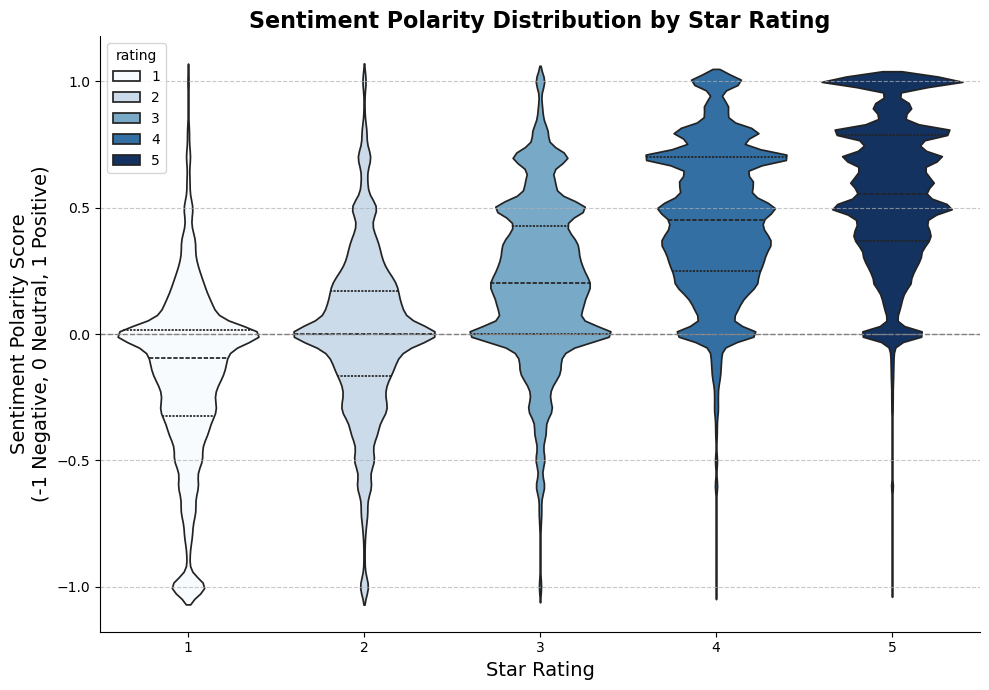

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))

# Violin plot using seaborn
sns.violinplot(x='rating', y='sentiment', data=df, palette='Blues', ax=ax, inner='quart', hue='rating')

# Customize the plot aesthetics
ax.set_title('Sentiment Polarity Distribution by Star Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=14)
ax.set_ylabel('Sentiment Polarity Score\n(-1 Negative, 0 Neutral, 1 Positive)', fontsize=14)

# Reference line for neutral sentiment
ax.axhline(0, color='grey', linestyle='--', linewidth=1)

# Adjust gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()


In [30]:
mean_sentiments = df.groupby('rating')['sentiment'].mean()
print(mean_sentiments)


rating
1   -0.154854
2   -0.000782
3    0.205467
4    0.440824
5    0.550836
Name: sentiment, dtype: float64


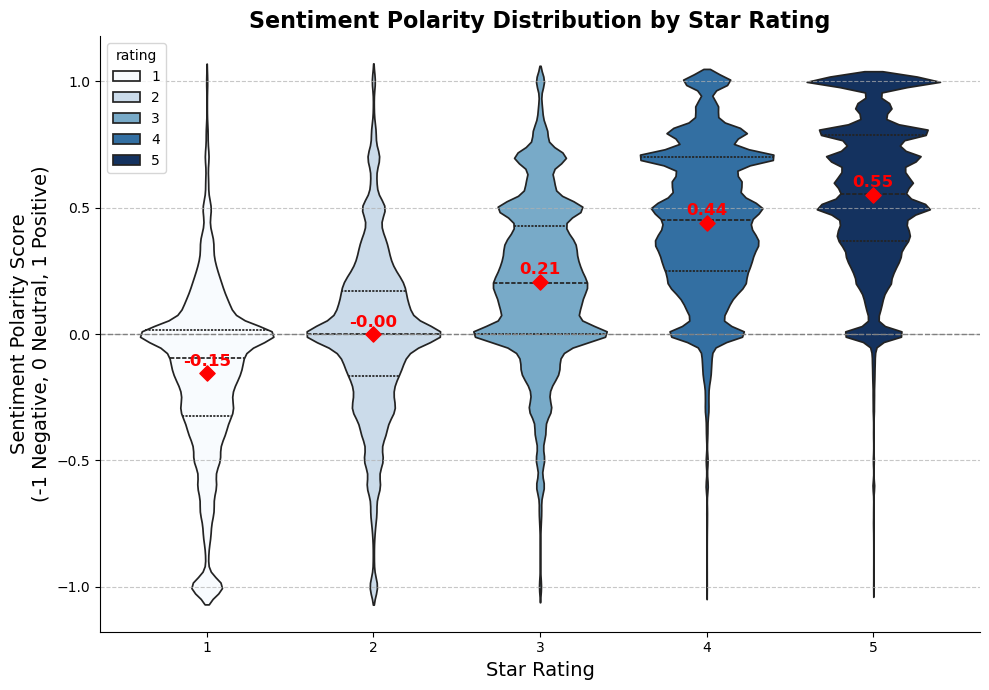

In [53]:
fig, ax = plt.subplots(figsize=(10, 7))

# Violin plot without hue (cleaner)
sns.violinplot(x='rating', y='sentiment', data=df, palette='Blues', ax=ax, inner='quart', hue='rating')

# Calculate means for each star rating
means = df.groupby('rating')['sentiment'].mean()

# Annotate each violin with the mean sentiment
for i, rating in enumerate(sorted(df['rating'].unique())):
    mean_val = means.loc[rating]
    ax.scatter(i, mean_val, color='red', s=60, zorder=10, marker='D')  # Mean point
    
    # Text annotation for mean
    ax.text(i, mean_val + 0.03, f'{mean_val:.2f}', 
            ha='center', fontsize=12, fontweight='bold', color='red')

# Plot aesthetics
ax.set_title('Sentiment Polarity Distribution by Star Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=14)
ax.set_ylabel('Sentiment Polarity Score\n(-1 Negative, 0 Neutral, 1 Positive)', fontsize=14)

# Neutral reference line
ax.axhline(0, color='grey', linestyle='--', linewidth=1)

# Gridlines for clarity
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()


## (5) Missing or Sparse Data Analysis

In [ ]:
df['short_review'] = df['word_count'] < 3

short_summary = df.groupby('rating')['short_review'].mean().reset_index()
short_summary.columns = ['rating', 'short_review_percentage']
short_summary['short_review_percentage'] *= 100  # convert to percentage

print(short_summary)

   rating  short_review_percentage
0       1                 4.855125
1       2                 4.977283
2       3                 8.804414
3       4                10.504926
4       5                11.203946


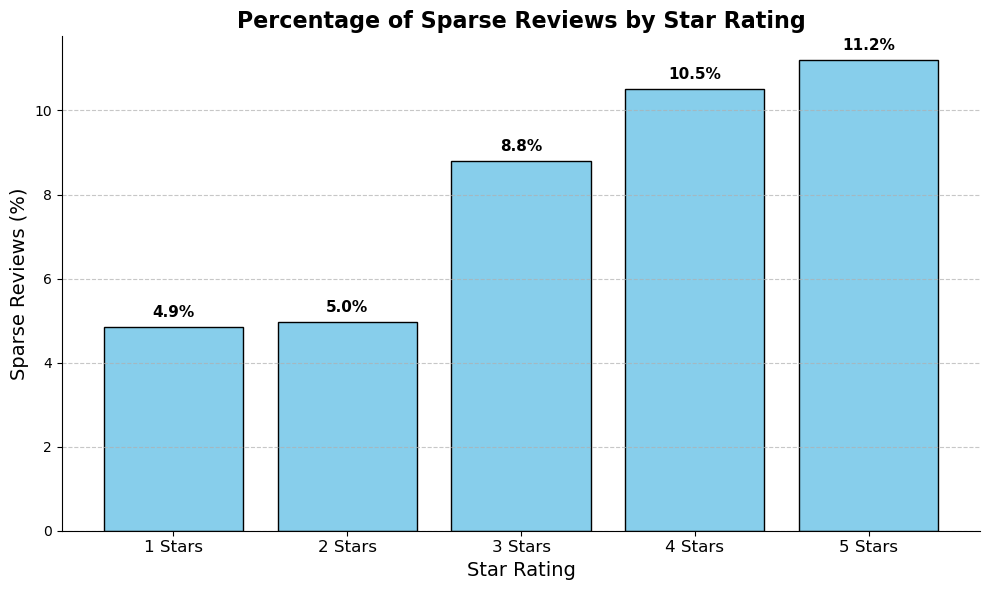

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    short_summary['rating'], 
    short_summary['short_review_percentage'], 
    color='skyblue', 
    edgecolor='black'
)

# Add percentage annotations on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),  # Offset annotation vertically
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold')

# Customize plot aesthetics
ax.set_title('Percentage of Sparse Reviews by Star Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=14)
ax.set_ylabel('Sparse Reviews (%)', fontsize=14)
ax.set_xticks(short_summary['rating'])
ax.set_xticklabels([f'{int(r)} Stars' for r in short_summary['rating']], fontsize=12)

# Gridlines for clarity
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Remove unnecessary spines
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()


Shorter ratings correlated with higher reviews...

## (6). Lexical Diversity


$$
\text{Lexical Diversity} = \frac{ \text{Number of unique words in review} }{ \text{Total number of words in reivew} }
$$

In [39]:
df['lexical_diversity'] = df['text'].apply(lambda x: len(set(x.split())) / len(x.split()))
diversity_summary = df['lexical_diversity'].describe()
print(diversity_summary)

count    1.230642e+06
mean     9.461903e-01
std      8.201115e-02
min      3.085339e-01
25%      9.032258e-01
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: lexical_diversity, dtype: float64


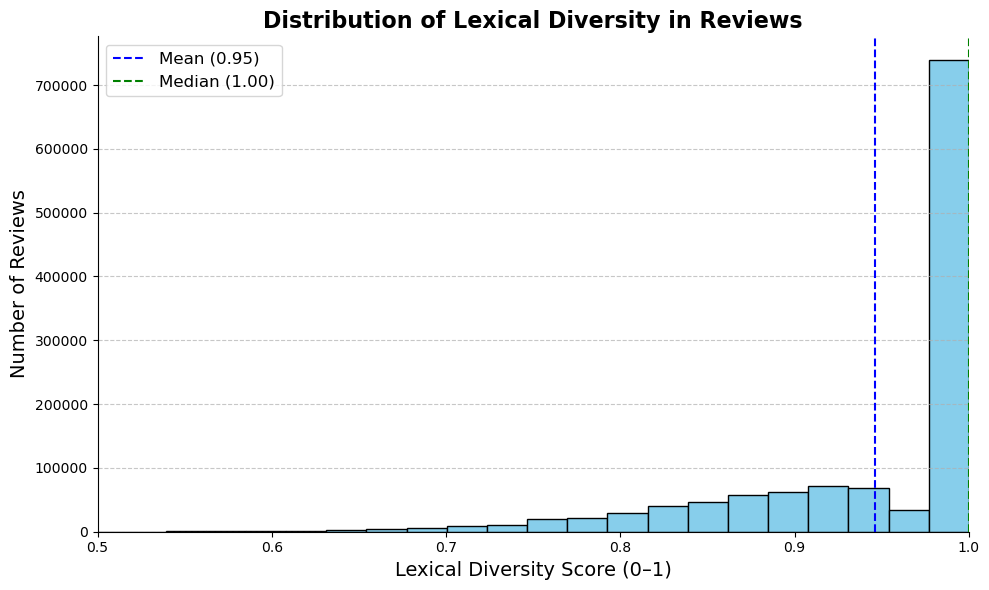

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Histogram of Lexical Diversity
ax.hist(df['lexical_diversity'], bins=30, color='skyblue', edgecolor='black')

# Calculate mean and median for annotations
mean_ld = df['lexical_diversity'].mean()
median_ld = df['lexical_diversity'].median()

# Mean and Median lines
ax.axvline(mean_ld, color='blue', linestyle='--', linewidth=1.5, label=f'Mean ({mean_ld:.2f})')
ax.axvline(median_ld, color='green', linestyle='--', linewidth=1.5, label=f'Median ({median_ld:.2f})')

# Customize plot aesthetics
ax.set_title('Distribution of Lexical Diversity in Reviews', fontsize=16, fontweight='bold')
ax.set_xlabel('Lexical Diversity Score (0–1)', fontsize=14)
ax.set_ylabel('Number of Reviews', fontsize=14)

# Legend clearly distinguishing mean and median
ax.legend(fontsize=12)

# Gridlines for clarity
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Remove unnecessary spines for cleaner look
ax.spines[['right', 'top']].set_visible(False)

ax.set_xlim(0.5, 1)

plt.tight_layout()
plt.show()


A value of 1 means no repeated words

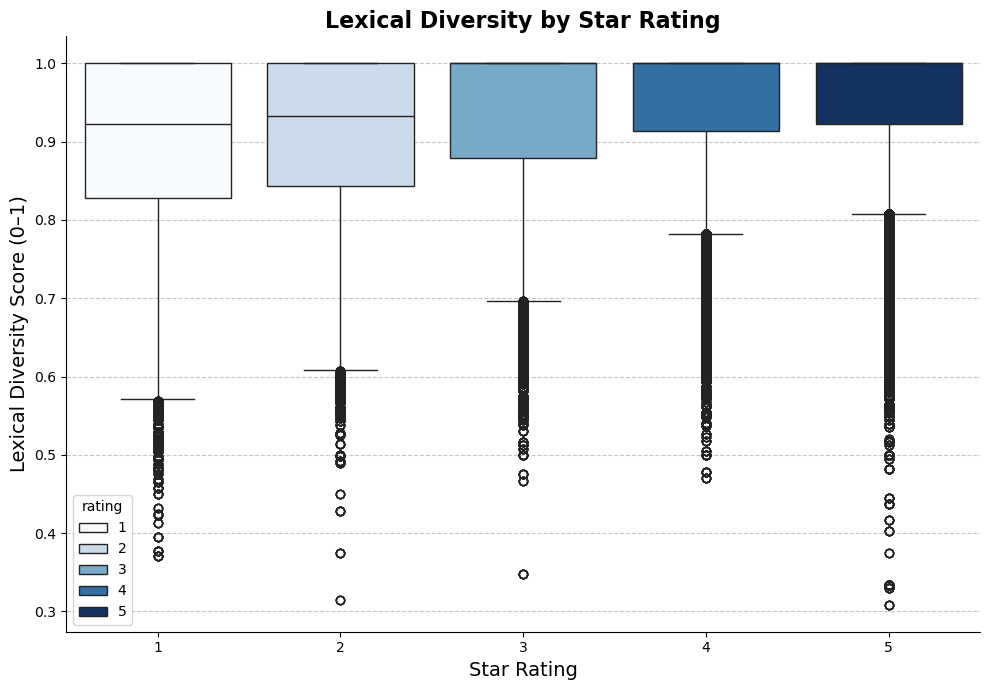

In [42]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 7))
sns.boxplot(x='rating', y='lexical_diversity', data=df, palette='Blues', ax=ax, hue='rating')

ax.set_title('Lexical Diversity by Star Rating', fontsize=16, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=14)
ax.set_ylabel('Lexical Diversity Score (0–1)', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()
